# Triagegeist — Phase 1 + Phase 2 (Merged)
**Run end-to-end on Kaggle. All outputs saved to `/kaggle/working/`**

## Section 1 — Setup & Data Loading

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

WORKING_DIR = '/kaggle/working/'
DATA_DIR    = '/kaggle/input/competitions/triagegeist/'

train_raw    = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
test_raw     = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
complaints   = pd.read_csv(os.path.join(DATA_DIR, 'chief_complaints.csv'))
patient_hist = pd.read_csv(os.path.join(DATA_DIR, 'patient_history.csv'))

complaints_clean = complaints[['patient_id', 'chief_complaint_raw']].rename(
    columns={'chief_complaint_raw': 'complaint_text'})

train = train_raw.merge(patient_hist, on='patient_id', how='left')
train = train.merge(complaints_clean, on='patient_id', how='left')
test  = test_raw.merge(patient_hist, on='patient_id', how='left')
test  = test.merge(complaints_clean, on='patient_id', how='left')

cols_to_drop = ['chief_complaint_system_x', 'chief_complaint_system_y', 'chief_complaint_system']
train = train.drop(columns=[c for c in cols_to_drop if c in train.columns])
test  = test.drop(columns=[c for c in cols_to_drop if c in test.columns])

TARGET     = 'triage_acuity'
DROP_COLS  = ['patient_id', 'site_id', 'triage_nurse_id',
              'disposition', 'ed_los_hours', 'complaint_text', TARGET]

train_text = train['complaint_text'].copy()
test_text  = test['complaint_text'].copy()

feature_cols = [c for c in train.columns if c not in DROP_COLS]
X_train_raw  = train[feature_cols].copy()
y_train      = train[TARGET]
X_test_raw   = test[feature_cols].copy()

print('Train:', train.shape, '| Test:', test.shape)
print('Target distribution:\n', y_train.value_counts().sort_index())

Train: (80000, 65) | Test: (20000, 62)
Target distribution:
 triage_acuity
1     3222
2    13439
3    28921
4    23020
5    11398
Name: count, dtype: int64


## Section 2 — Exploratory Data Analysis

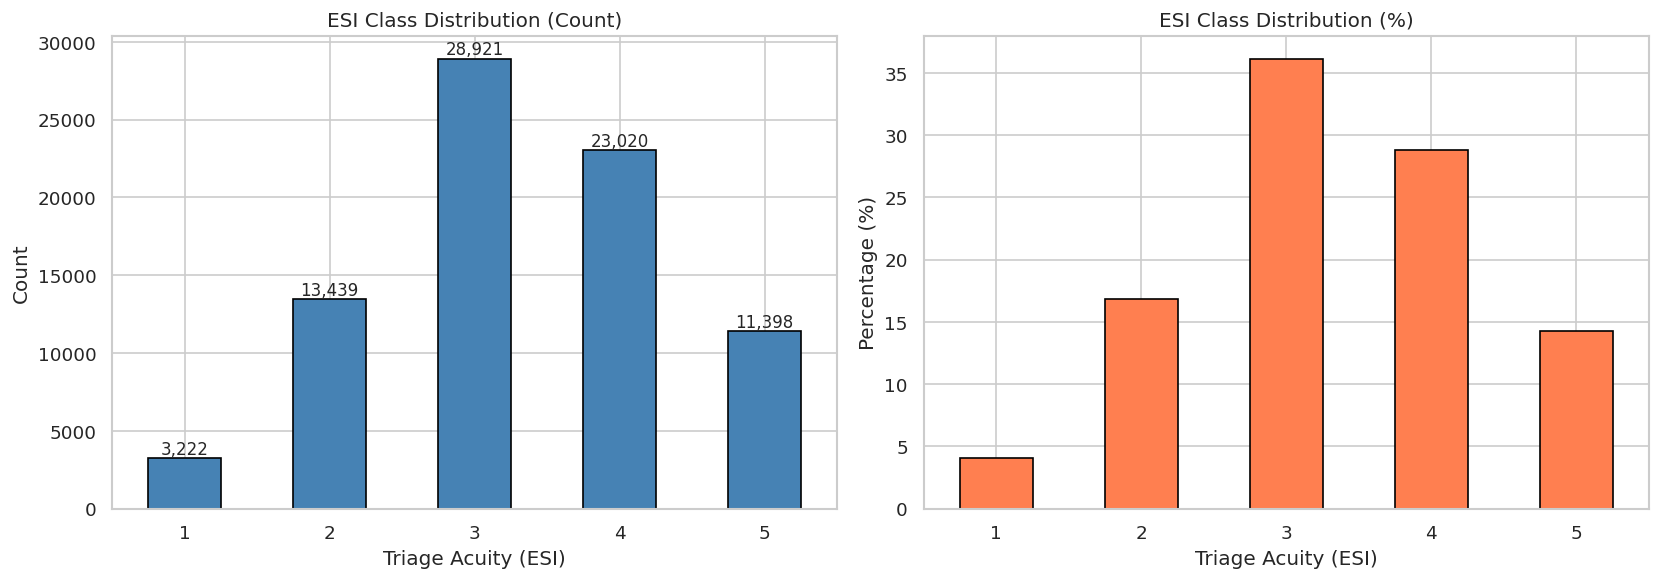

Class counts:
 triage_acuity
1     3222
2    13439
3    28921
4    23020
5    11398
Name: count, dtype: int64


In [2]:
# --- 2.1 Class Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
y_train.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('ESI Class Distribution (Count)')
axes[0].set_xlabel('Triage Acuity (ESI)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)
(y_train.value_counts().sort_index() / len(y_train) * 100).plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('ESI Class Distribution (%)')
axes[1].set_xlabel('Triage Acuity (ESI)')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig(WORKING_DIR + 'eda_class_distribution.png')
plt.show()
print('Class counts:\n', y_train.value_counts().sort_index())

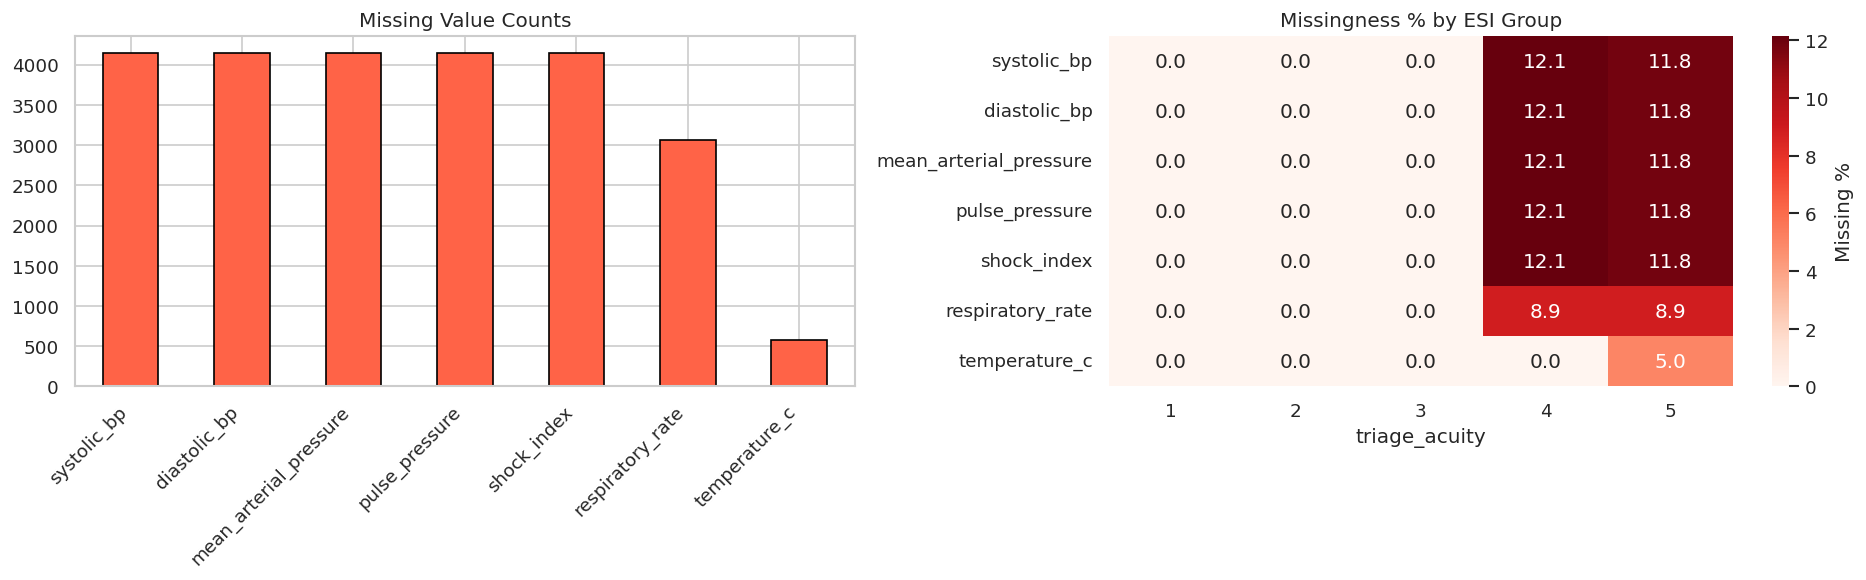

Missing value summary:
 systolic_bp               4146
diastolic_bp              4146
mean_arterial_pressure    4146
pulse_pressure            4146
shock_index               4146
respiratory_rate          3067
temperature_c              574
dtype: int64


In [3]:
# --- 2.2 Missingness Heatmap ---
missing = X_train_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
missing.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('Missing Value Counts')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
train_with_target = X_train_raw.copy()
train_with_target['triage_acuity'] = y_train.values
miss_by_esi = train_with_target.groupby('triage_acuity')[missing.index.tolist()].apply(
    lambda x: x.isnull().mean() * 100)
sns.heatmap(miss_by_esi.T, annot=True, fmt='.1f', cmap='Reds', ax=axes[1],
            cbar_kws={'label': 'Missing %'})
axes[1].set_title('Missingness % by ESI Group')
plt.tight_layout()
plt.savefig(WORKING_DIR + 'eda_missingness.png')
plt.show()
print('Missing value summary:\n', missing)

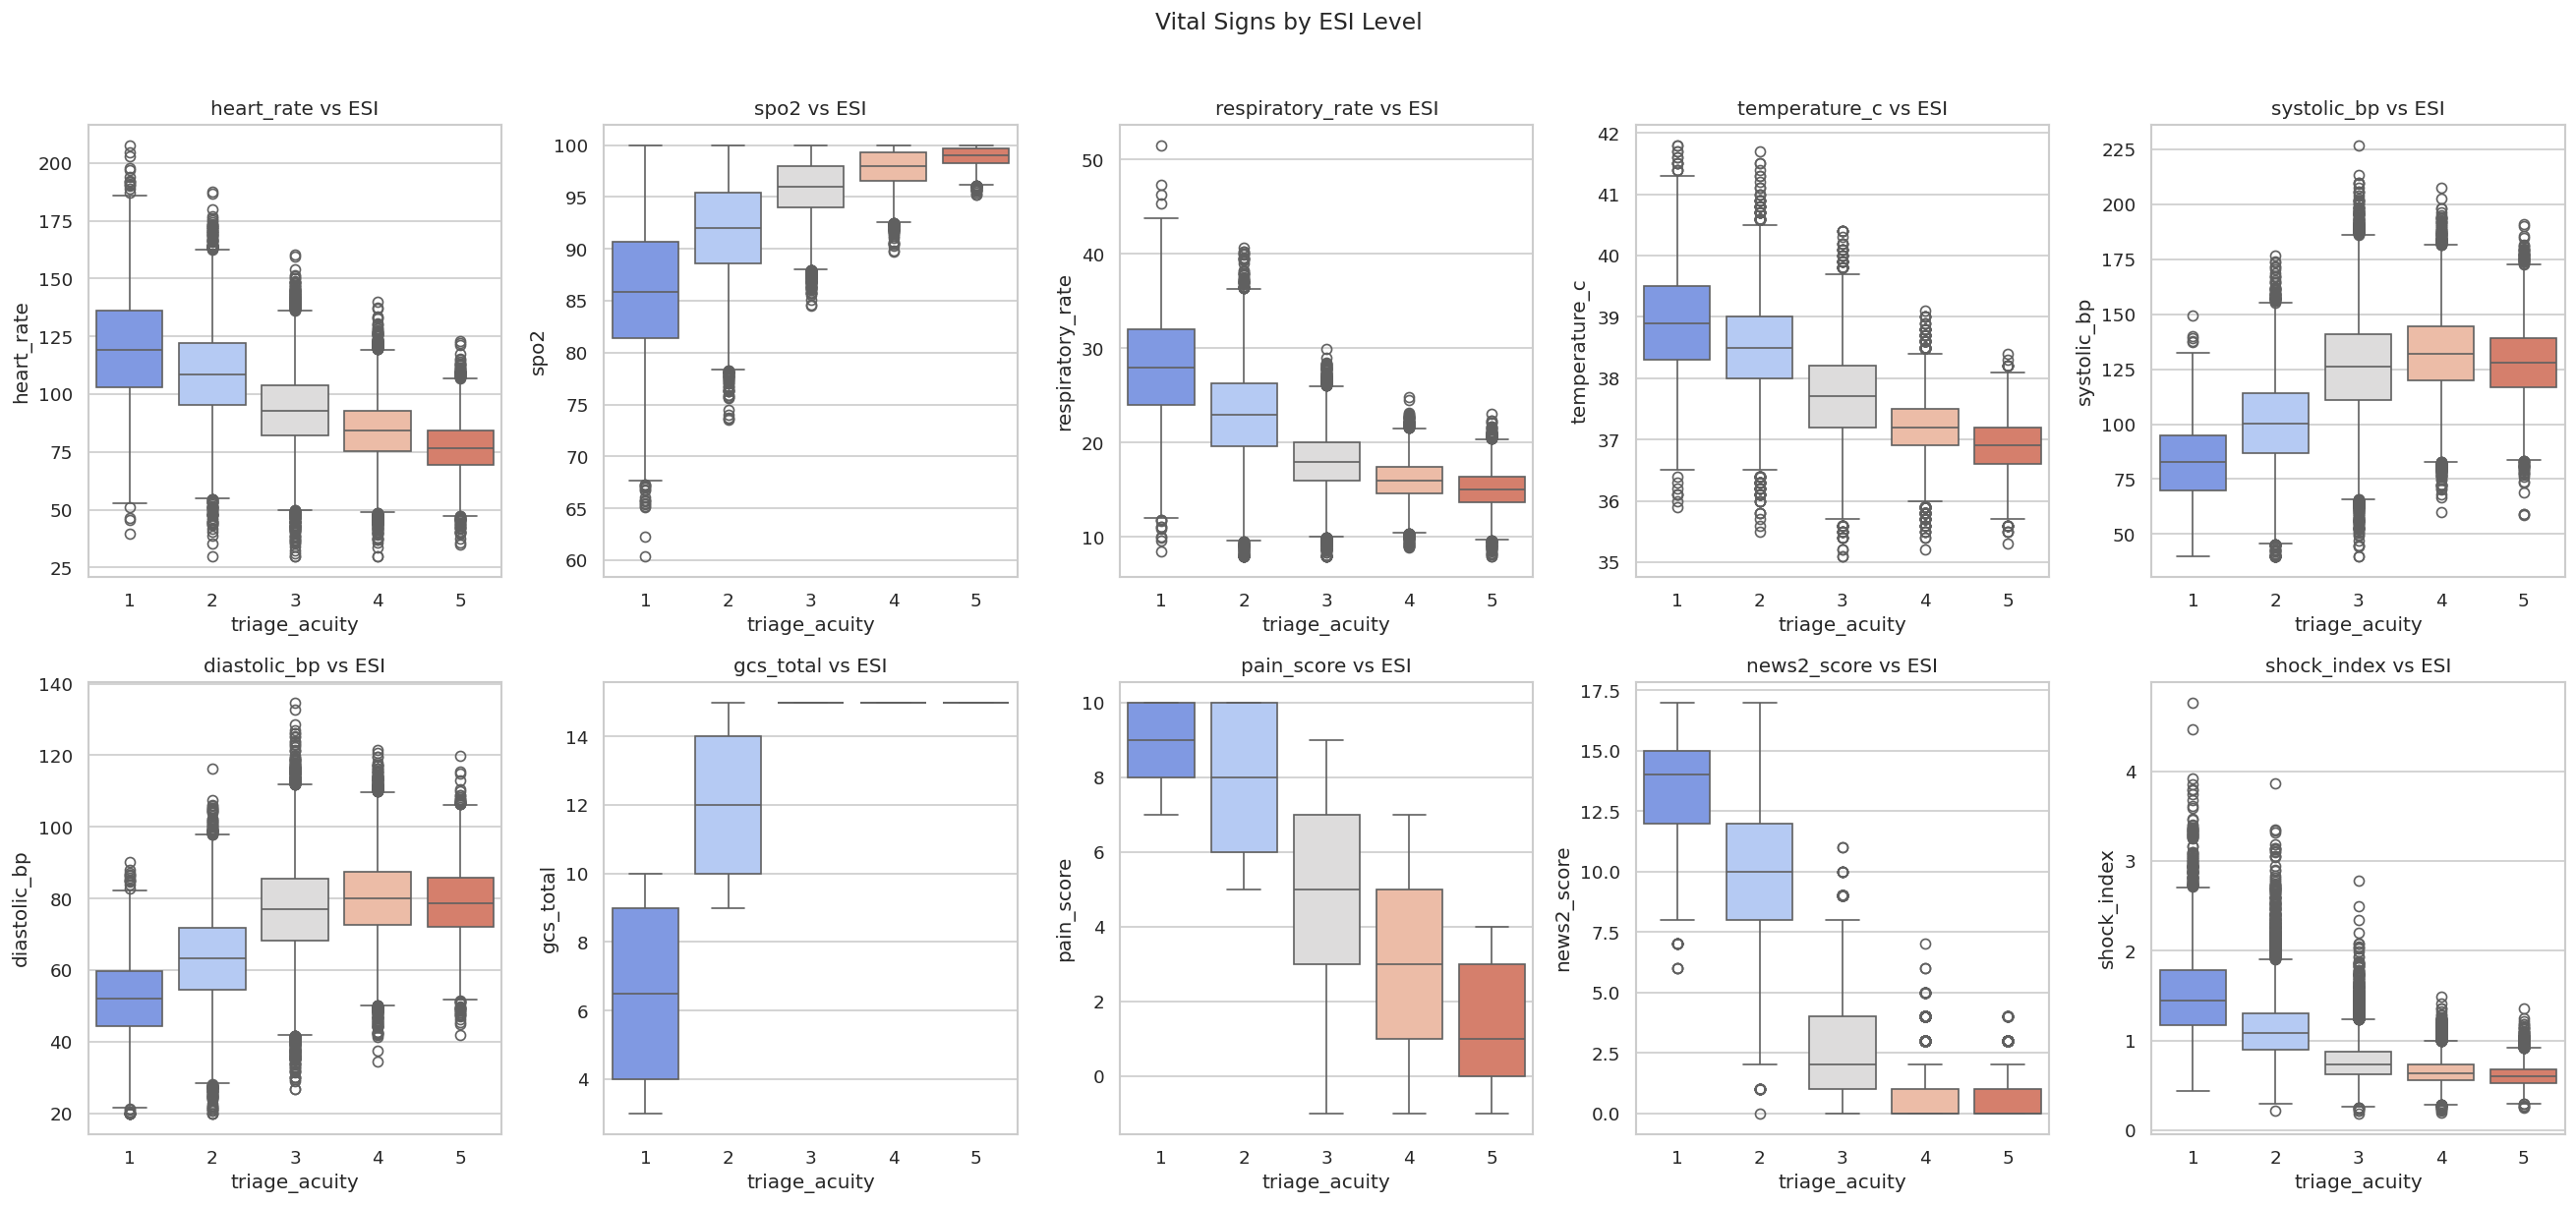

In [4]:
# --- 2.3 Vitals Boxplots ---
vital_cols = ['heart_rate', 'spo2', 'respiratory_rate', 'temperature_c',
              'systolic_bp', 'diastolic_bp', 'gcs_total', 'pain_score',
              'news2_score', 'shock_index']
train_plot = X_train_raw[vital_cols].copy()
train_plot['triage_acuity'] = y_train.values
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()
for i, col in enumerate(vital_cols):
    sns.boxplot(data=train_plot, x='triage_acuity', y=col, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{col} vs ESI')
plt.suptitle('Vital Signs by ESI Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(WORKING_DIR + 'eda_vitals_boxplots.png')
plt.show()

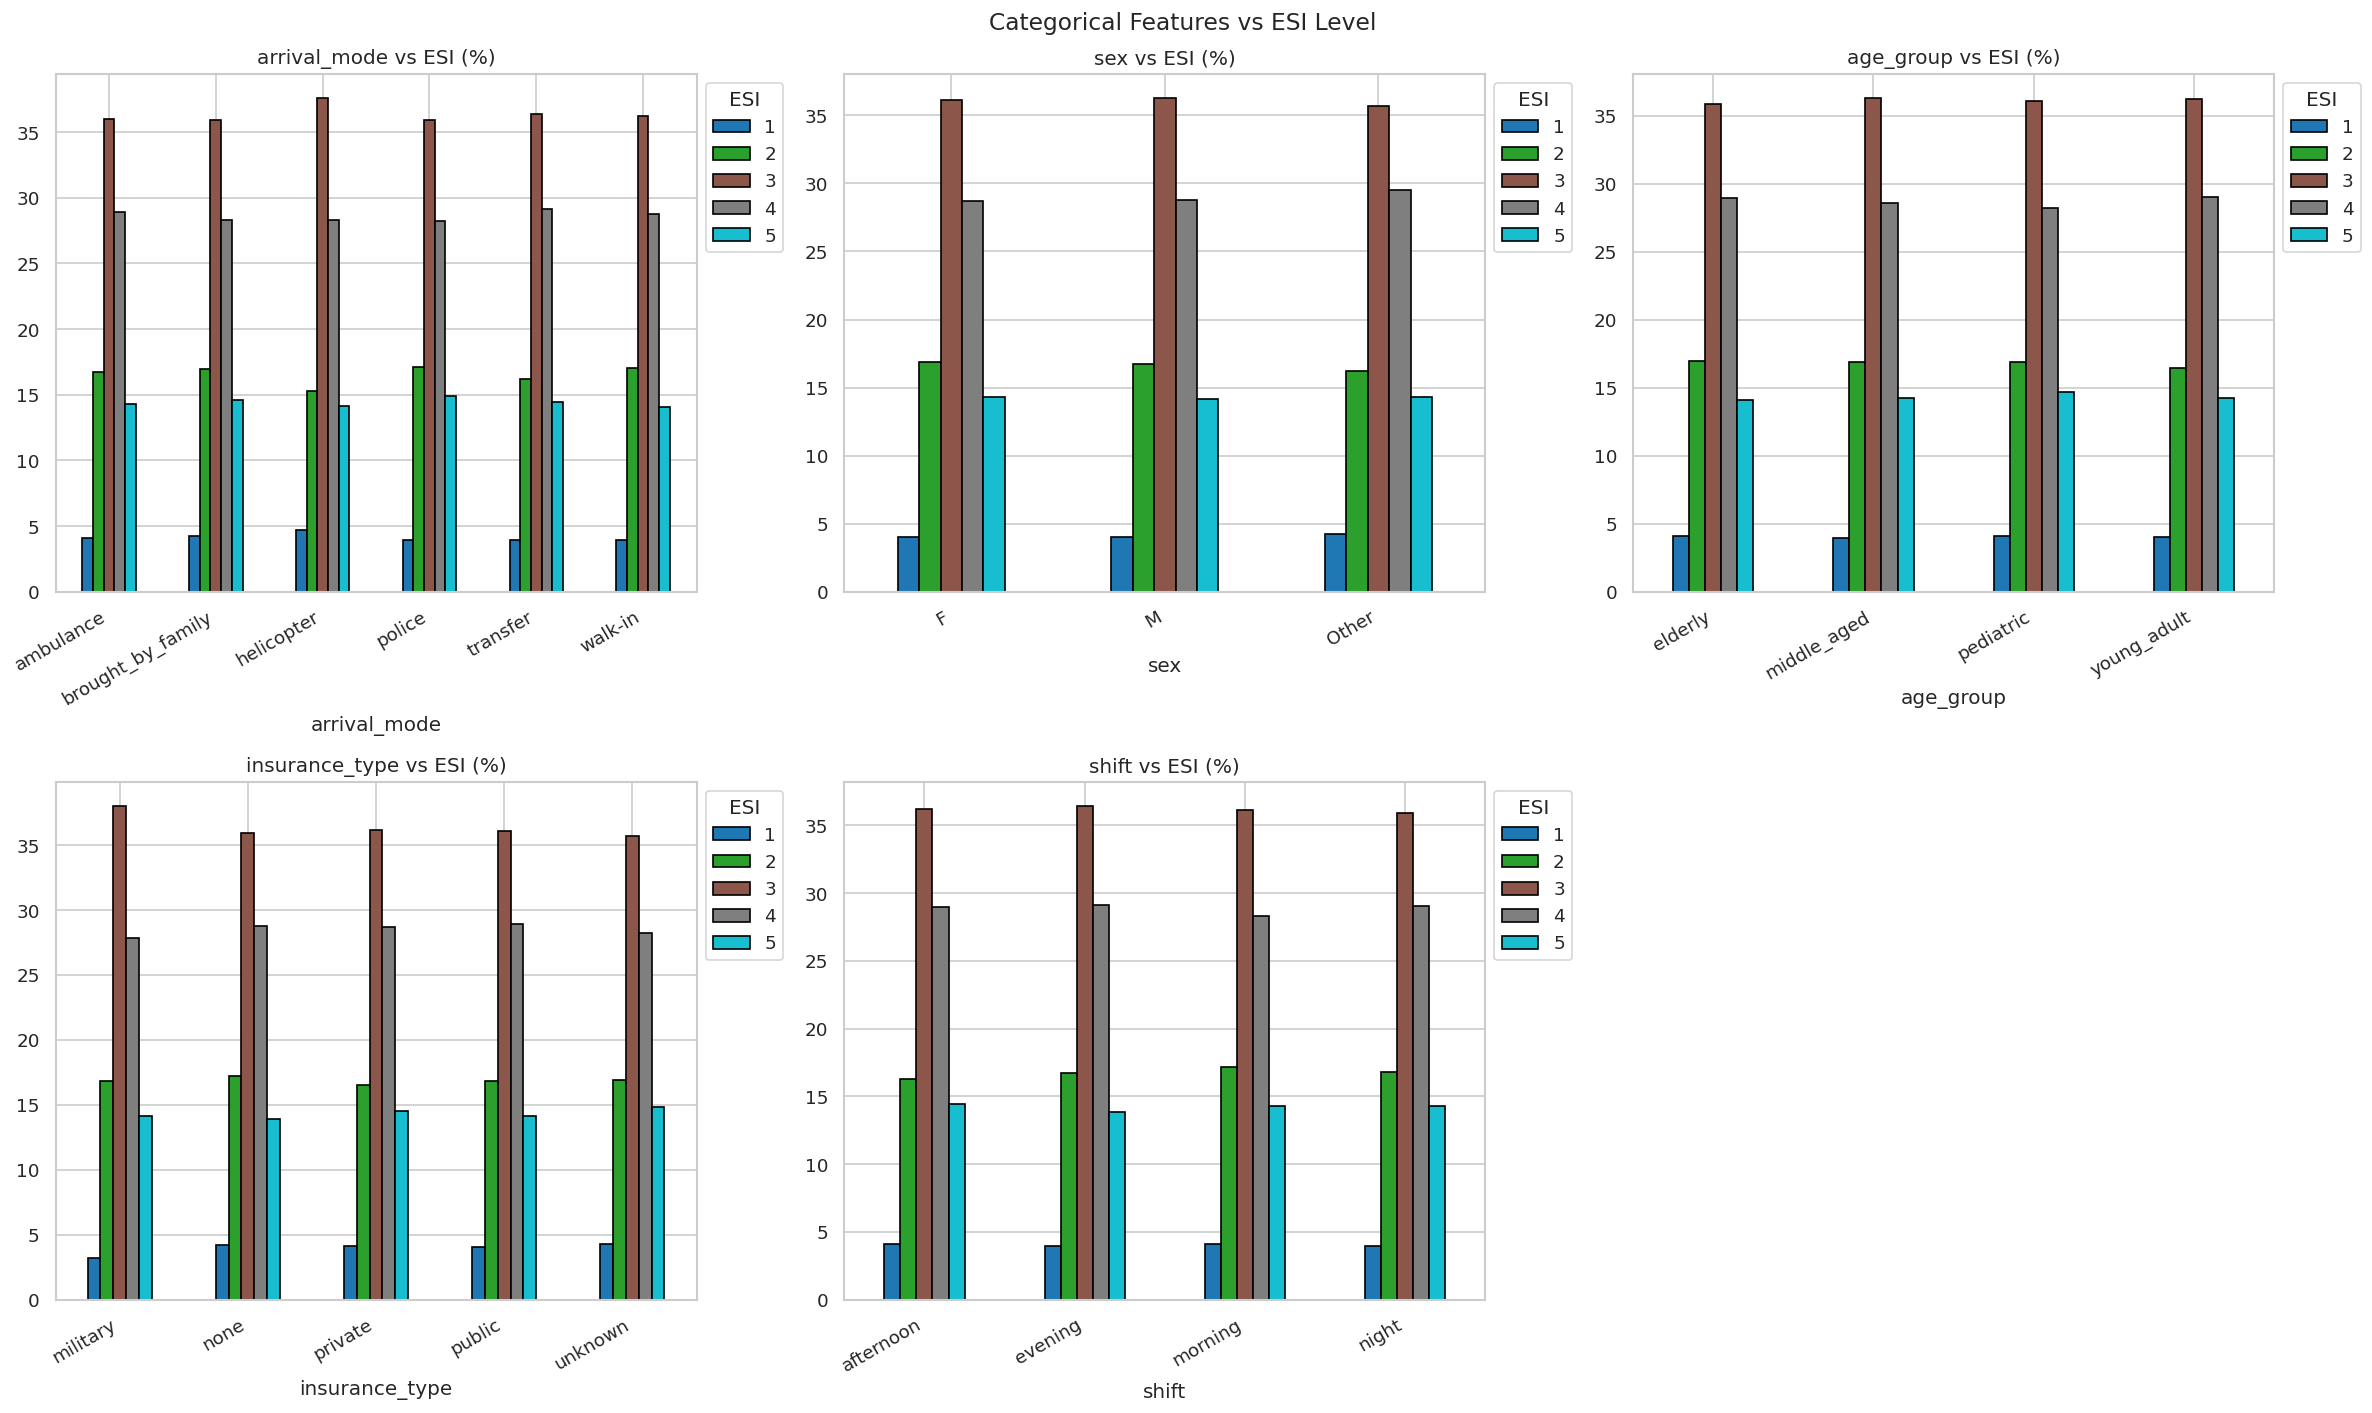

In [5]:
# --- 2.4 Categorical Features ---
cat_cols_eda = ['arrival_mode', 'sex', 'age_group', 'insurance_type', 'shift']
train_cat = X_train_raw[cat_cols_eda].copy()
train_cat['triage_acuity'] = y_train.values
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols_eda):
    ct = pd.crosstab(train_cat[col], train_cat['triage_acuity'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], colormap='tab10', edgecolor='black')
    axes[i].set_title(f'{col} vs ESI (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].legend(title='ESI', bbox_to_anchor=(1, 1))
axes[-1].set_visible(False)
plt.suptitle('Categorical Features vs ESI Level', fontsize=14)
plt.tight_layout()
plt.savefig(WORKING_DIR + 'eda_categorical.png')
plt.show()

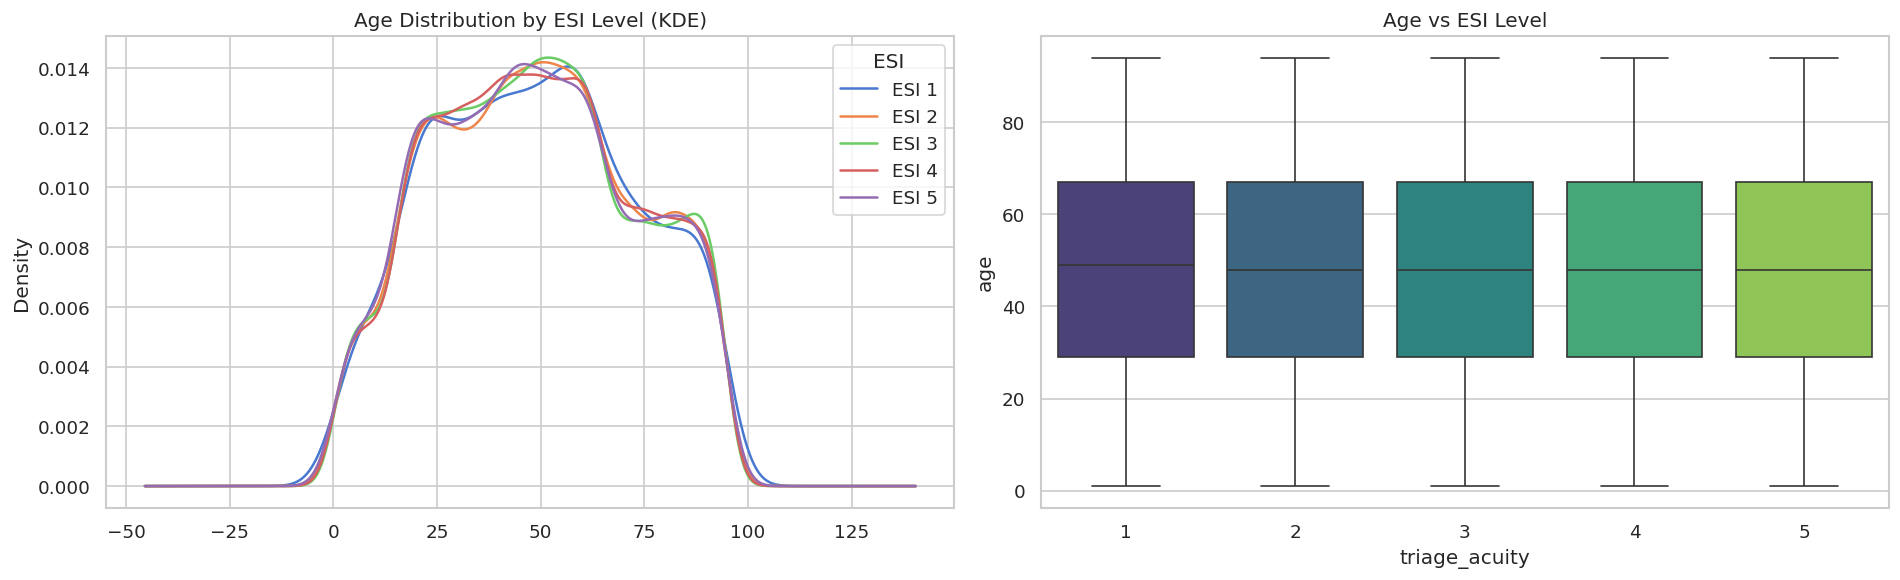

Median age by ESI:
 triage_acuity
1    49.0
2    48.0
3    48.0
4    48.0
5    48.0
Name: age, dtype: float64


In [6]:
# --- 2.5 Age Distribution ---
train_age = X_train_raw[['age']].copy()
train_age['triage_acuity'] = y_train.values
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for esi in sorted(train_age['triage_acuity'].unique()):
    train_age[train_age['triage_acuity'] == esi]['age'].plot(kind='kde', ax=axes[0], label=f'ESI {esi}')
axes[0].set_title('Age Distribution by ESI Level (KDE)')
axes[0].legend(title='ESI')
sns.boxplot(data=train_age, x='triage_acuity', y='age', ax=axes[1], palette='viridis')
axes[1].set_title('Age vs ESI Level')
plt.tight_layout()
plt.savefig(WORKING_DIR + 'eda_age.png')
plt.show()
print('Median age by ESI:\n', train_age.groupby('triage_acuity')['age'].median())

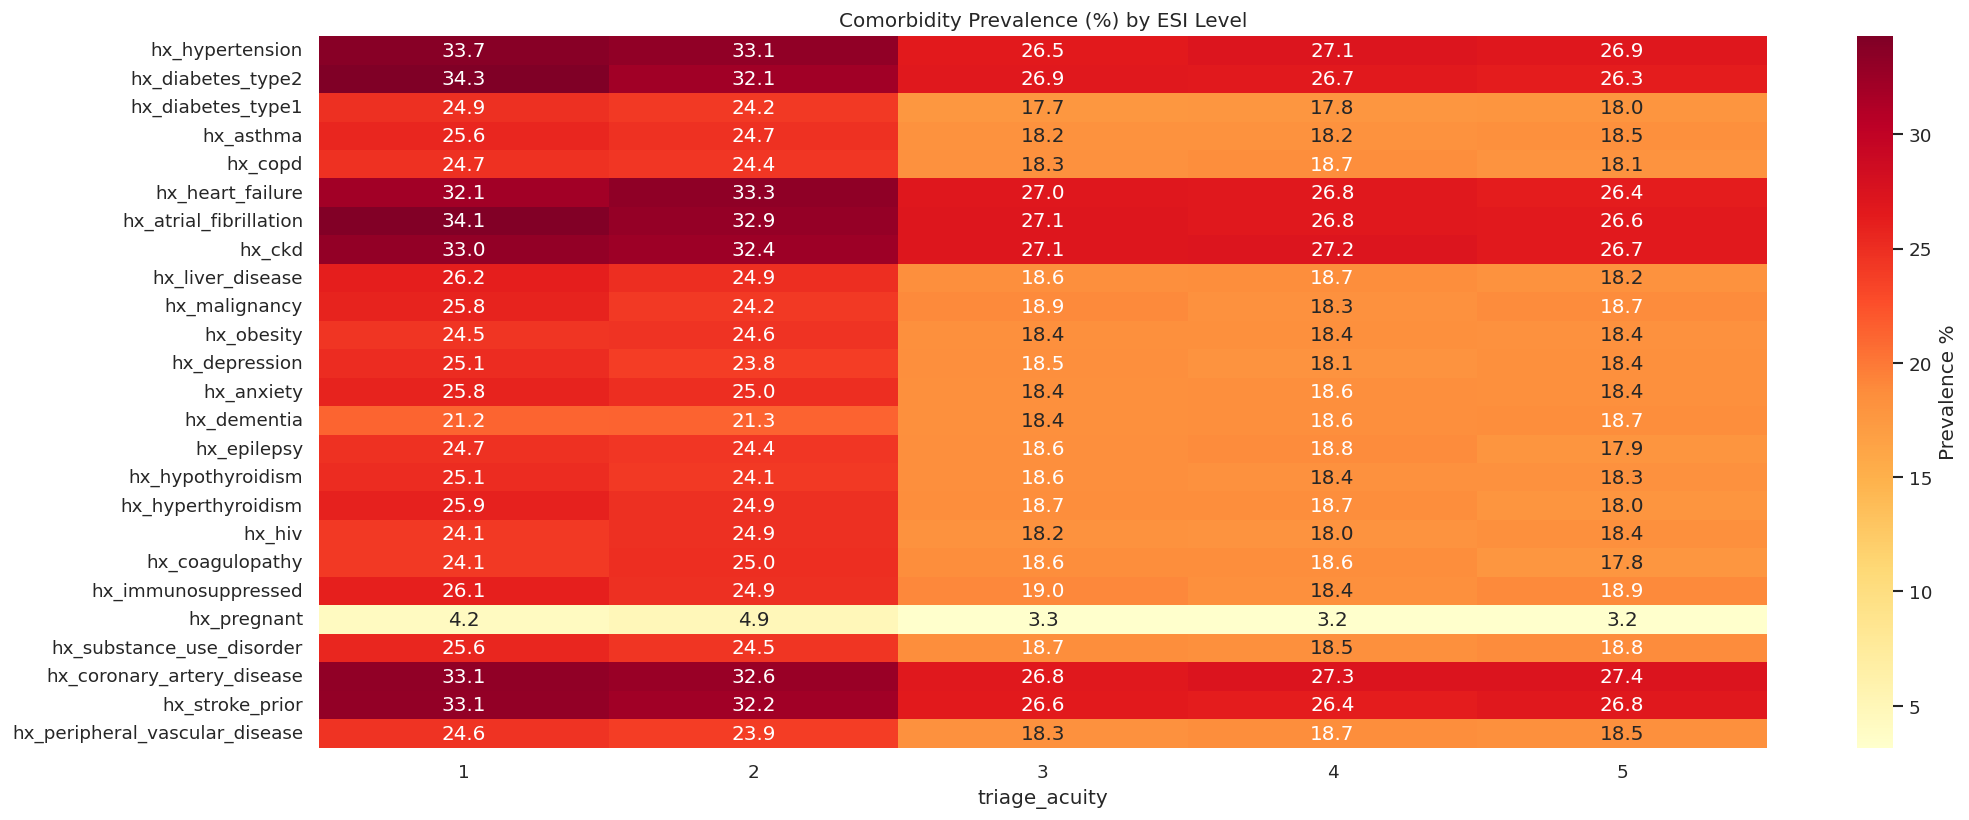

In [7]:
# --- 2.6 Comorbidity Heatmap ---
hx_cols = [c for c in X_train_raw.columns if c.startswith('hx_')]
train_hx = X_train_raw[hx_cols].copy()
train_hx['triage_acuity'] = y_train.values
hx_by_esi = train_hx.groupby('triage_acuity')[hx_cols].mean() * 100
fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(hx_by_esi.T, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Prevalence %'})
ax.set_title('Comorbidity Prevalence (%) by ESI Level')
plt.tight_layout()
plt.savefig(WORKING_DIR + 'eda_comorbidities.png')
plt.show()

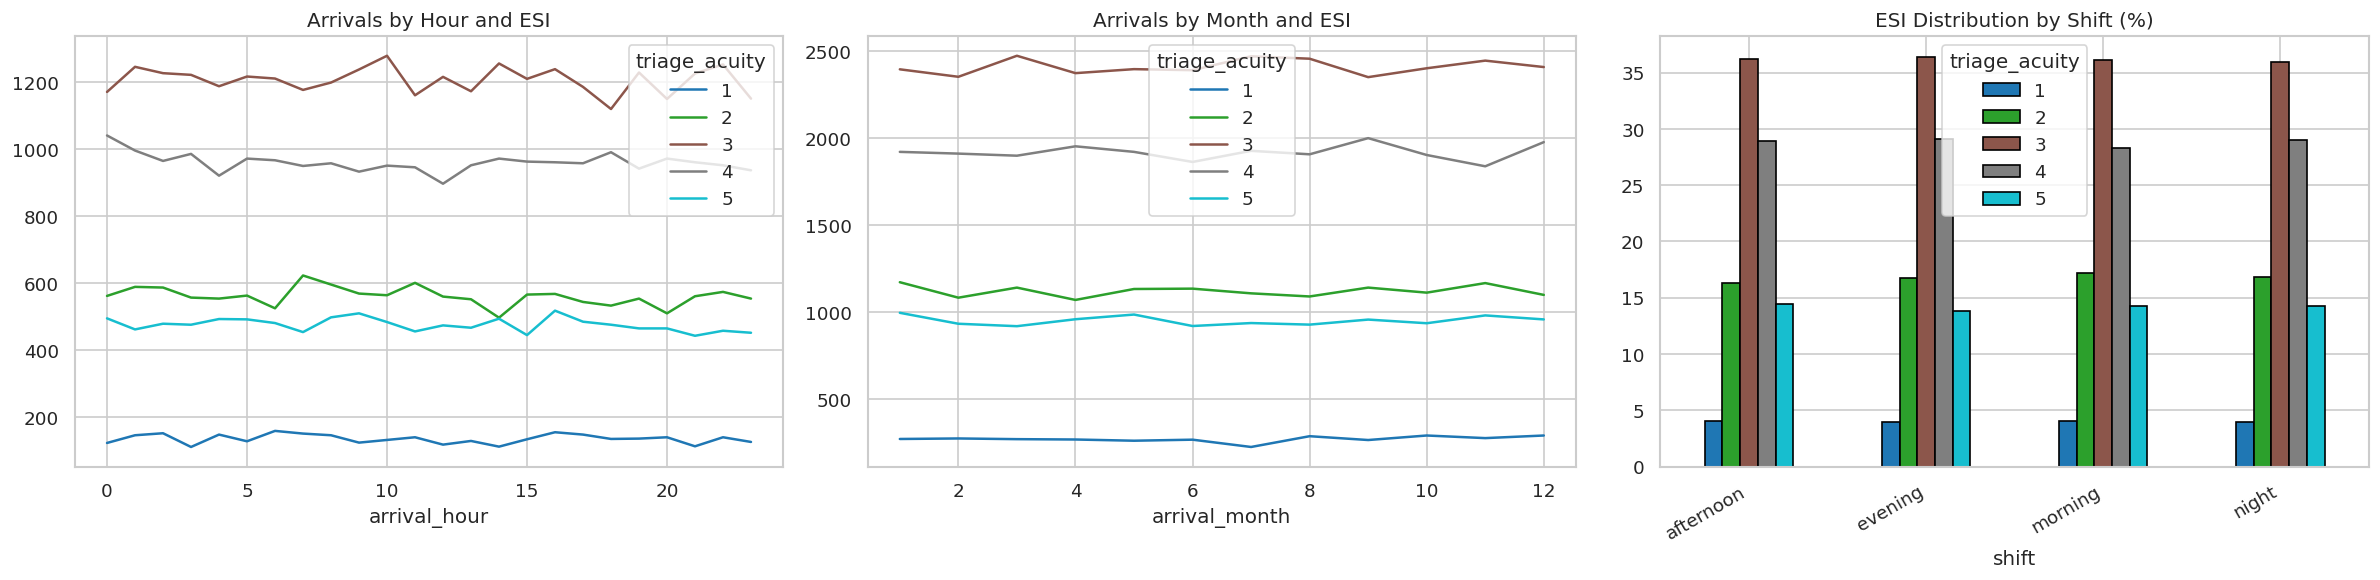

In [8]:
# --- 2.7 Temporal Patterns ---
train_time = X_train_raw[['arrival_hour', 'arrival_day', 'arrival_month', 'shift']].copy()
train_time['triage_acuity'] = y_train.values
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
train_time.groupby(['arrival_hour', 'triage_acuity']).size().unstack().plot(ax=axes[0], colormap='tab10')
axes[0].set_title('Arrivals by Hour and ESI')
train_time.groupby(['arrival_month', 'triage_acuity']).size().unstack().plot(ax=axes[1], colormap='tab10')
axes[1].set_title('Arrivals by Month and ESI')
pd.crosstab(train_time['shift'], train_time['triage_acuity'], normalize='index').mul(100).plot(
    kind='bar', ax=axes[2], colormap='tab10', edgecolor='black')
axes[2].set_title('ESI Distribution by Shift (%)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.savefig(WORKING_DIR + 'eda_temporal.png')
plt.show()

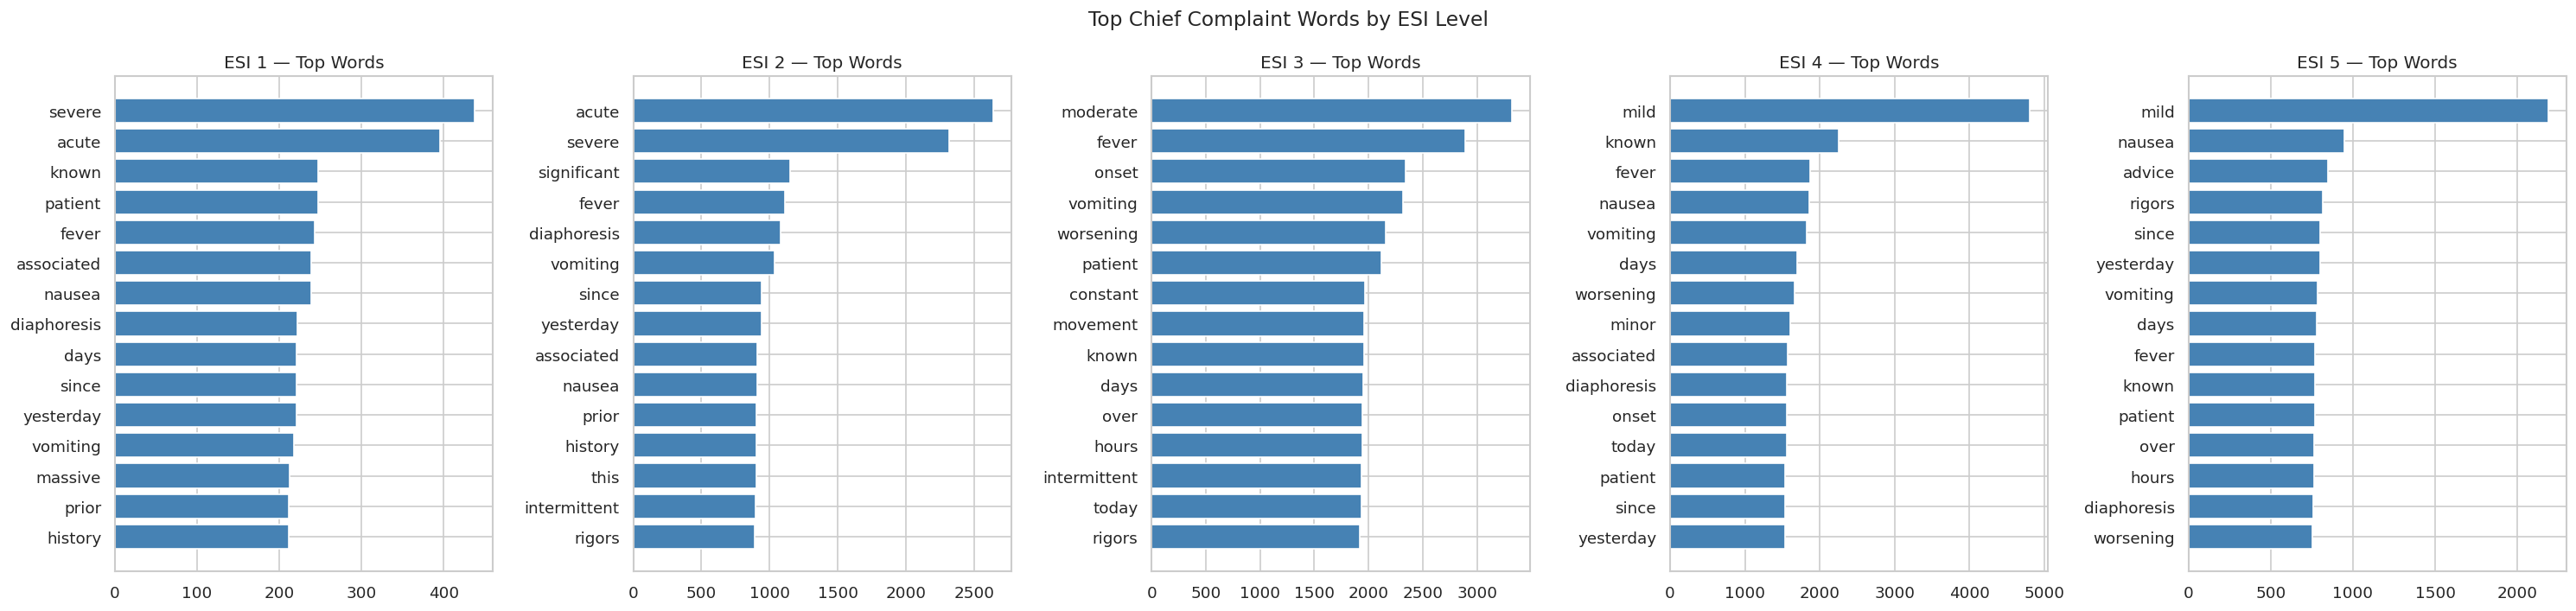

In [9]:
# --- 2.8 Chief Complaint Word Frequency ---
train_text_df = pd.DataFrame({'complaint_text': train_text.values, 'triage_acuity': y_train.values})
fig, axes = plt.subplots(1, 5, figsize=(25, 6))
stopwords = {'the', 'a', 'and', 'of', 'to', 'in', 'with', 'no', 'for', 'on'}
for esi in range(1, 6):
    subset = train_text_df[train_text_df['triage_acuity'] == esi]['complaint_text']
    words  = ' '.join(subset.dropna()).lower().split()
    words  = [w for w in words if w not in stopwords and len(w) > 2]
    top    = Counter(words).most_common(15)
    wl, ct = zip(*top)
    axes[esi-1].barh(wl[::-1], ct[::-1], color='steelblue')
    axes[esi-1].set_title(f'ESI {esi} — Top Words')
plt.suptitle('Top Chief Complaint Words by ESI Level', fontsize=14)
plt.tight_layout()
plt.savefig(WORKING_DIR + 'eda_complaints_wordfreq.png')
plt.show()

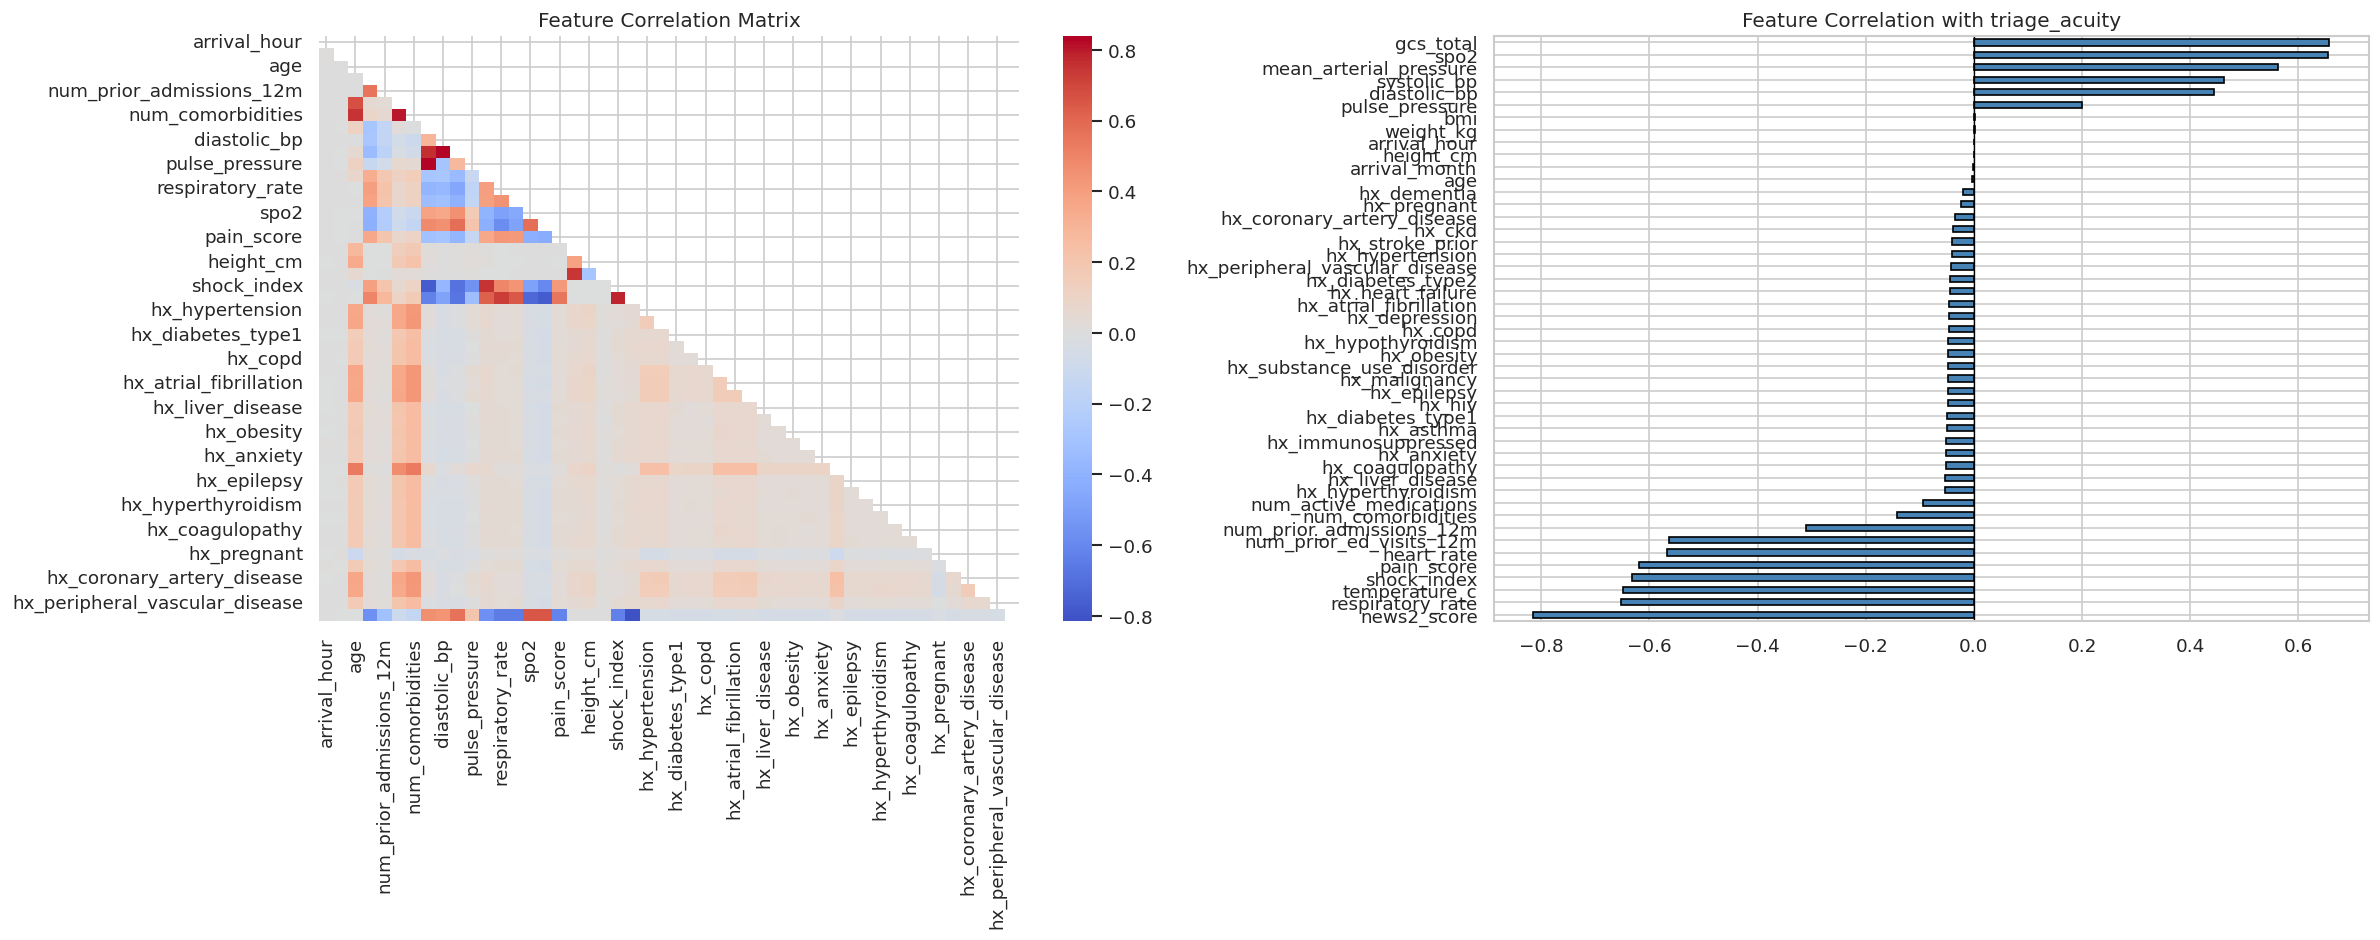

Top 10 features correlated with target:
 news2_score                0.814804
gcs_total                  0.656620
spo2                       0.654399
respiratory_rate           0.652945
temperature_c              0.649193
shock_index                0.631830
pain_score                 0.618834
heart_rate                 0.567962
num_prior_ed_visits_12m    0.564138
mean_arterial_pressure     0.561726
Name: triage_acuity, dtype: float64


In [10]:
# --- 2.9 Correlation Heatmap ---
numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
train_corr = X_train_raw[numeric_cols].copy()
train_corr['triage_acuity'] = y_train.values
corr_matrix = train_corr.corr()
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, ax=axes[0], annot=False)
axes[0].set_title('Feature Correlation Matrix')
target_corr = corr_matrix['triage_acuity'].drop('triage_acuity').sort_values()
target_corr.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Feature Correlation with triage_acuity')
axes[1].axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(WORKING_DIR + 'eda_correlation.png')
plt.show()
print('Top 10 features correlated with target:\n',
      target_corr.abs().sort_values(ascending=False).head(10))

In [11]:
# --- 2.10 Outlier / Range Check ---
vital_check = ['heart_rate','spo2','respiratory_rate','temperature_c',
               'systolic_bp','diastolic_bp','gcs_total','pain_score',
               'age','bmi','weight_kg','height_cm']
print('=== Outlier / Range Check ===\n')
for col in vital_check:
    if col in X_train_raw.columns:
        print(f'{col}: min={X_train_raw[col].min():.1f}, max={X_train_raw[col].max():.1f}, '
              f'mean={X_train_raw[col].mean():.1f}, null={X_train_raw[col].isnull().sum()}')
print('\nPain score -1 count:', (X_train_raw['pain_score'] == -1).sum())

=== Outlier / Range Check ===

heart_rate: min=30.0, max=207.7, mean=91.9, null=0
spo2: min=60.4, max=100.0, mean=95.8, null=0
respiratory_rate: min=8.0, max=51.5, mean=18.3, null=3067
temperature_c: min=35.1, max=41.8, mean=37.6, null=574
systolic_bp: min=40.0, max=226.9, mean=121.6, null=4146
diastolic_bp: min=20.0, max=134.8, mean=74.5, null=4146
gcs_total: min=3.0, max=15.0, mean=14.2, null=0
pain_score: min=-1.0, max=10.0, mean=4.5, null=0
age: min=1.0, max=94.0, mean=48.5, null=0
bmi: min=10.0, max=65.0, mean=26.4, null=0
weight_kg: min=2.0, max=148.5, mean=74.5, null=0
height_cm: min=45.0, max=210.0, mean=168.6, null=0

Pain score -1 count: 11156


## Section 3 — Phase 1 Baseline Model
Simple LightGBM on structured features only. No NLP. Establishes the score to beat.

In [12]:
# --- 3.1 Pain score fix + simple imputation + encode (baseline only) ---
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, cohen_kappa_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

X_bl = X_train_raw.copy()
X_bl_test = X_test_raw.copy()

# Pain sentinel fix
X_bl['pain_missing']      = (X_bl['pain_score'] == -1).astype(int)
X_bl_test['pain_missing'] = (X_bl_test['pain_score'] == -1).astype(int)
X_bl['pain_score']        = X_bl['pain_score'].replace(-1, float('nan'))
X_bl_test['pain_score']   = X_bl_test['pain_score'].replace(-1, float('nan'))

# Simple global median imputation
for col in X_bl.columns:
    if X_bl[col].isnull().sum() > 0:
        m = X_bl[col].median()
        X_bl[col]      = X_bl[col].fillna(m)
        X_bl_test[col] = X_bl_test[col].fillna(m)

# Label encode categoricals
cat_cols_bl = X_bl.select_dtypes(include=['object']).columns.tolist()
le_dict_bl  = {}
for col in cat_cols_bl:
    le = LabelEncoder()
    combined = pd.concat([X_bl[col], X_bl_test[col]]).astype(str)
    le.fit(combined)
    X_bl[col]      = le.transform(X_bl[col].astype(str))
    X_bl_test[col] = le.transform(X_bl_test[col].astype(str))
    le_dict_bl[col] = le

print('Nulls after imputation:', X_bl.isnull().sum().sum())
print('Baseline feature count:', X_bl.shape[1])

Nulls after imputation: 0
Baseline feature count: 59


In [13]:
# --- 3.2 Baseline LightGBM 5-fold CV ---
y = y_train.values - 1  # 0-indexed

classes = np.unique(y)
weights = compute_class_weight('balanced', classes=classes, y=y)
class_weight_dict = dict(zip(classes, weights))
sample_weights    = np.array([class_weight_dict[yi] for yi in y])

baseline_params = {
    'objective': 'multiclass', 'num_class': 5, 'metric': 'multi_logloss',
    'num_leaves': 63, 'learning_rate': 0.05, 'feature_fraction': 0.8,
    'bagging_fraction': 0.8, 'bagging_freq': 5, 'min_child_samples': 20,
    'verbose': -1, 'random_state': 42, 'n_jobs': -1
}

skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_bl     = np.zeros((len(X_bl), 5))
test_bl    = np.zeros((len(X_bl_test), 5))
bl_f1s, bl_kappas = [], []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_bl, y)):
    print(f'\n--- Baseline Fold {fold+1}/5 ---')
    X_tr, X_val = X_bl.iloc[tr_idx], X_bl.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    sw_tr       = sample_weights[tr_idx]
    dtrain = lgb.Dataset(X_tr, label=y_tr, weight=sw_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    mdl = lgb.train(baseline_params, dtrain, num_boost_round=1000,
                    valid_sets=[dval],
                    callbacks=[lgb.early_stopping(50, verbose=False),
                                lgb.log_evaluation(100)])
    vp = mdl.predict(X_val)
    oof_bl[val_idx] = vp
    test_bl += mdl.predict(X_bl_test) / 5
    f1    = f1_score(y_val, np.argmax(vp,1), average='weighted')
    kappa = cohen_kappa_score(y_val, np.argmax(vp,1), weights='quadratic')
    bl_f1s.append(f1); bl_kappas.append(kappa)
    print(f'Fold {fold+1} — F1: {f1:.4f} | QWK: {kappa:.4f}')

oof_f1    = f1_score(y, np.argmax(oof_bl,1), average='weighted')
oof_kappa = cohen_kappa_score(y, np.argmax(oof_bl,1), weights='quadratic')
oof_acc   = (np.argmax(oof_bl,1) == y).mean()

print('\n========== BASELINE RESULTS ==========')
print(f'OOF Weighted F1 : {oof_f1:.4f}')
print(f'OOF QWK         : {oof_kappa:.4f}')
print(f'OOF Accuracy    : {oof_acc:.4f}')
print('======================================')
print(classification_report(y, np.argmax(oof_bl,1),
      target_names=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5']))

# Save
np.save(WORKING_DIR + 'oof_baseline.npy', oof_bl)
np.save(WORKING_DIR + 'test_baseline.npy', test_bl)
print('Baseline predictions saved.')


--- Baseline Fold 1/5 ---
[100]	valid_0's multi_logloss: 0.338282
[200]	valid_0's multi_logloss: 0.333265
Fold 1 — F1: 0.8525 | QWK: 0.9308

--- Baseline Fold 2/5 ---
[100]	valid_0's multi_logloss: 0.347314
[200]	valid_0's multi_logloss: 0.340593
Fold 2 — F1: 0.8475 | QWK: 0.9274

--- Baseline Fold 3/5 ---
[100]	valid_0's multi_logloss: 0.33792
[200]	valid_0's multi_logloss: 0.330949
Fold 3 — F1: 0.8526 | QWK: 0.9287

--- Baseline Fold 4/5 ---
[100]	valid_0's multi_logloss: 0.339254
[200]	valid_0's multi_logloss: 0.333374
Fold 4 — F1: 0.8525 | QWK: 0.9308

--- Baseline Fold 5/5 ---
[100]	valid_0's multi_logloss: 0.34445
[200]	valid_0's multi_logloss: 0.337825
Fold 5 — F1: 0.8495 | QWK: 0.9289

========== BASELINE RESULTS ==========
OOF Weighted F1 : 0.8509
OOF QWK         : 0.9293
OOF Accuracy    : 0.8503
              precision    recall  f1-score   support

       ESI 1       0.95      0.94      0.94      3222
       ESI 2       0.97      0.97      0.97     13439
       ESI 3       

## Section 4 — Phase 2: Structured Feature Engineering

In [14]:
# --- 4.1 Missingness flags (before imputation) ---
missing_flag_cols = ['systolic_bp','diastolic_bp','mean_arterial_pressure',
                     'pulse_pressure','shock_index','respiratory_rate','temperature_c']
for col in missing_flag_cols:
    if col in train.columns:
        train[f'{col}_missing'] = train[col].isnull().astype(int)
        test[f'{col}_missing']  = test[col].isnull().astype(int)

train['pain_missing'] = (train['pain_score'] == -1).astype(int)
test['pain_missing']  = (test['pain_score']  == -1).astype(int)
train['pain_score']   = train['pain_score'].replace(-1, float('nan'))
test['pain_score']    = test['pain_score'].replace(-1, float('nan'))

flag_cols = [c for c in train.columns if c.endswith('_missing')]
print('Missingness flags added:')
print(train[flag_cols].sum())

Missingness flags added:
systolic_bp_missing                4146
diastolic_bp_missing               4146
mean_arterial_pressure_missing     4146
pulse_pressure_missing             4146
shock_index_missing                4146
respiratory_rate_missing           3067
temperature_c_missing               574
pain_missing                      11156
dtype: int64


In [15]:
# --- 4.2 ESI-group aware median imputation ---
impute_cols = ['systolic_bp','diastolic_bp','mean_arterial_pressure',
               'pulse_pressure','shock_index','respiratory_rate','temperature_c','pain_score']
esi_medians = train.groupby(TARGET)[impute_cols].median()
print('ESI-group medians:\n', esi_medians.round(2))

for col in impute_cols:
    if col in train.columns:
        for esi_level in train[TARGET].unique():
            mask = (train[TARGET] == esi_level) & (train[col].isnull())
            train.loc[mask, col] = esi_medians.loc[esi_level, col]

for col in impute_cols:
    if col in test.columns:
        test[col] = test[col].fillna(train[col].median())

print('Nulls after imputation (train):', train[impute_cols].isnull().sum().sum())
print('Nulls after imputation (test): ', test[impute_cols].isnull().sum().sum())

ESI-group medians:
                systolic_bp  diastolic_bp  mean_arterial_pressure  \
triage_acuity                                                      
1                     82.6         52.15                    62.1   
2                    100.4         63.30                    75.5   
3                    126.0         76.90                    93.3   
4                    132.0         80.00                    97.3   
5                    128.1         78.80                    95.3   

               pulse_pressure  shock_index  respiratory_rate  temperature_c  \
triage_acuity                                                                 
1                        30.3         1.45              28.0           38.9   
2                        37.3         1.08              23.0           38.5   
3                        49.3         0.74              18.0           37.7   
4                        52.1         0.64              16.0           37.2   
5                        49.0

In [16]:
# --- 4.3 Cyclical time encoding ---
for col in ['arrival_hour', 'arrival_day', 'arrival_month']:
    train[col] = pd.to_numeric(train[col], errors='coerce')
    test[col]  = pd.to_numeric(test[col],  errors='coerce')

train['arrival_hour_sin']  = np.sin(2*np.pi*train['arrival_hour']/24)
train['arrival_hour_cos']  = np.cos(2*np.pi*train['arrival_hour']/24)
test['arrival_hour_sin']   = np.sin(2*np.pi*test['arrival_hour']/24)
test['arrival_hour_cos']   = np.cos(2*np.pi*test['arrival_hour']/24)
train['arrival_day_sin']   = np.sin(2*np.pi*train['arrival_day']/7)
train['arrival_day_cos']   = np.cos(2*np.pi*train['arrival_day']/7)
test['arrival_day_sin']    = np.sin(2*np.pi*test['arrival_day']/7)
test['arrival_day_cos']    = np.cos(2*np.pi*test['arrival_day']/7)
train['arrival_month_sin'] = np.sin(2*np.pi*train['arrival_month']/12)
train['arrival_month_cos'] = np.cos(2*np.pi*train['arrival_month']/12)
test['arrival_month_sin']  = np.sin(2*np.pi*test['arrival_month']/12)
test['arrival_month_cos']  = np.cos(2*np.pi*test['arrival_month']/12)

train = train.drop(columns=['arrival_hour','arrival_day','arrival_month'])
test  = test.drop(columns=['arrival_hour','arrival_day','arrival_month'])
print('Cyclical time features added.')

Cyclical time features added.


In [17]:
# --- 4.4 Label encode categoricals ---
from sklearn.preprocessing import LabelEncoder

DROP_COLS = ['patient_id','site_id','triage_nurse_id',
             'disposition','ed_los_hours','complaint_text',TARGET]
feature_cols   = [c for c in train.columns if c not in DROP_COLS]
X_train_eng    = train[feature_cols].copy()
X_test_eng     = test[feature_cols].copy()
y              = train[TARGET].values - 1

cat_cols = X_train_eng.select_dtypes(include=['object']).columns.tolist()
print('Encoding:', cat_cols)
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X_train_eng[col], X_test_eng[col]]).astype(str)
    le.fit(combined)
    X_train_eng[col] = le.transform(X_train_eng[col].astype(str))
    X_test_eng[col]  = le.transform(X_test_eng[col].astype(str))
    le_dict[col] = le

print('X_train_eng shape:', X_train_eng.shape)
print('Remaining nulls:',   X_train_eng.isnull().sum().sum())

Encoding: ['arrival_mode', 'arrival_season', 'shift', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage']
X_train_eng shape: (80000, 69)
Remaining nulls: 160000


## Section 5 — Phase 2: NLP Branch

In [18]:
# --- 5.1 Keyword risk flags ---
import re

keyword_patterns = {
    'kw_chest_pain':          r'chest pain',
    'kw_shortness_of_breath': r'short(ness)? of breath|sob|dyspn',
    'kw_syncope':             r'syncope|fainted|passed out',
    'kw_altered_ms':          r'altered mental status|confusion|disoriented|ams',
    'kw_stroke':              r'stroke|facial droop|arm weakness|slurred speech',
    'kw_unresponsive':        r'unresponsive|unconscious|not responding',
    'kw_severe_pain':         r'severe pain|10/10|worst pain',
    'kw_diaphoresis':         r'diaphoresis|diaphoretic|sweating profusely',
    'kw_hypotension':         r'hypotension|hypotensive|low blood pressure',
    'kw_trauma':              r'trauma|mvc|motor vehicle|fall from|gunshot|stab',
    'kw_cardiac_arrest':      r'cardiac arrest|no pulse|pulseless',
    'kw_seizure':             r'seizure|convulsion|fitting',
    'kw_severe':              r'\bsevere\b',
    'kw_acute':               r'\bacute\b',
    'kw_massive':             r'\bmassive\b',
}

def add_keyword_flags(text_series):
    return pd.DataFrame({
        name: text_series.str.contains(pat, case=False, regex=True, na=False).astype(int)
        for name, pat in keyword_patterns.items()
    })

train_keywords = add_keyword_flags(train_text)
test_keywords  = add_keyword_flags(test_text)
print('Keyword flags shape:', train_keywords.shape)
print(train_keywords.sum().sort_values(ascending=False))

Keyword flags shape: (80000, 15)
kw_diaphoresis            5493
kw_acute                  4795
kw_severe                 4328
kw_trauma                 3675
kw_shortness_of_breath    1379
kw_altered_ms             1076
kw_chest_pain             1026
kw_stroke                  647
kw_syncope                 397
kw_unresponsive            257
kw_massive                 213
kw_seizure                 147
kw_cardiac_arrest           83
kw_severe_pain               0
kw_hypotension               0
dtype: int64


In [19]:
# --- 5.2 TF-IDF features ---
from sklearn.feature_extraction.text import TfidfVectorizer

train_text_filled = train_text.fillna('').astype(str)
test_text_filled  = test_text.fillna('').astype(str)

tfidf = TfidfVectorizer(max_features=300, ngram_range=(1,2),
                         min_df=5, max_df=0.95, sublinear_tf=True)
tfidf.fit(train_text_filled)

train_tfidf_arr = tfidf.transform(train_text_filled).toarray()
test_tfidf_arr  = tfidf.transform(test_text_filled).toarray()

tfidf_cols     = [f'tfidf_{i}' for i in range(train_tfidf_arr.shape[1])]
train_tfidf_df = pd.DataFrame(train_tfidf_arr, columns=tfidf_cols)
test_tfidf_df  = pd.DataFrame(test_tfidf_arr,  columns=tfidf_cols)
print('TF-IDF shape:', train_tfidf_df.shape)

TF-IDF shape: (80000, 300)


In [21]:
# --- 5.3 Bio_ClinicalBERT embeddings ---
# NOTE: Enable GPU in Kaggle (Settings → Accelerator → GPU P100) before running this cell
import torch
from transformers import AutoTokenizer, AutoModel

device = torch.device('cpu')
print(f'Using device: {device}')

# If running Kaggle offline, add Bio_ClinicalBERT as a dataset input and use:
# model_path = '/kaggle/input/bio-clinicalbert/emilyalsentzer/Bio_ClinicalBERT'
model_path = 'emilyalsentzer/Bio_ClinicalBERT'

tokenizer  = AutoTokenizer.from_pretrained(model_path)
bert_model = AutoModel.from_pretrained(model_path).to(device)
bert_model.eval()
print('Bio_ClinicalBERT loaded.')

def get_bert_embeddings(texts, batch_size=32):
    all_emb = []
    texts = texts.fillna('').astype(str).tolist()
    for i in range(0, len(texts), batch_size):
        batch   = texts[i:i+batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True,
                             max_length=128, return_tensors='pt')
        encoded = {k: v.to(device) for k, v in encoded.items()}
        with torch.no_grad():
            out = bert_model(**encoded)
        all_emb.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        if (i // batch_size) % 10 == 0:
            print(f'  {i+len(batch)}/{len(texts)} texts processed')
    return np.vstack(all_emb)

print('Generating train BERT embeddings...')
train_bert = get_bert_embeddings(train_text)
print('Generating test BERT embeddings...')
test_bert  = get_bert_embeddings(test_text)

np.save(WORKING_DIR + 'train_bert.npy', train_bert)
np.save(WORKING_DIR + 'test_bert.npy',  test_bert)
print(f'BERT embeddings saved. Shape: {train_bert.shape}')

Using device: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Bio_ClinicalBERT loaded.
Generating train BERT embeddings...
  32/80000 texts processed
  352/80000 texts processed
  672/80000 texts processed
  992/80000 texts processed
  1312/80000 texts processed
  1632/80000 texts processed
  1952/80000 texts processed
  2272/80000 texts processed
  2592/80000 texts processed
  2912/80000 texts processed
  3232/80000 texts processed
  3552/80000 texts processed
  3872/80000 texts processed
  4192/80000 texts processed
  4512/80000 texts processed
  4832/80000 texts processed
  5152/80000 texts processed
  5472/80000 texts processed
  5792/80000 texts processed
  6112/80000 texts processed
  6432/80000 texts processed
  6752/80000 texts processed
  7072/80000 texts processed
  7392/80000 texts processed
  7712/80000 texts processed
  8032/80000 texts processed
  8352/80000 texts processed
  8672/80000 texts processed
  8992/80000 texts processed
  9312/80000 texts processed
  9632/80000 texts processed
  9952/80000 texts processed
  10272/80000 te

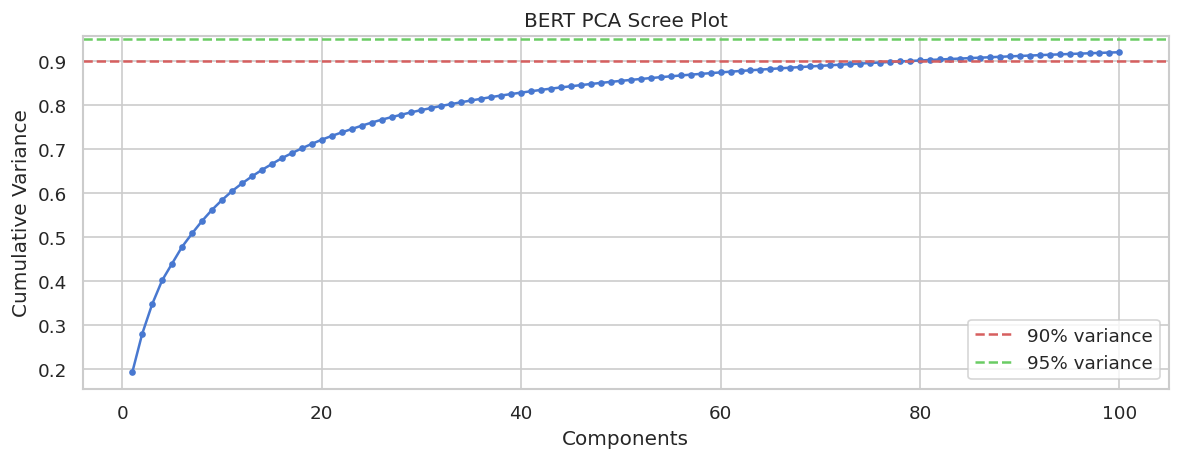

Components for 90% variance: 79
Components for 95% variance: 1
BERT PCA shape: (80000, 64) | Variance retained: 0.881


In [22]:
# --- 5.4 PCA compression 768 → 64 ---
from sklearn.decomposition import PCA

# Load from disk (safe if kernel restarted after BERT cell)
train_bert = np.load(WORKING_DIR + 'train_bert.npy')
test_bert  = np.load(WORKING_DIR + 'test_bert.npy')

# Scree plot
pca_check = PCA(n_components=100)
pca_check.fit(train_bert)
cumvar = np.cumsum(pca_check.explained_variance_ratio_)

plt.figure(figsize=(10,4))
plt.plot(range(1,101), cumvar, marker='o', markersize=3)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Components'); plt.ylabel('Cumulative Variance')
plt.title('BERT PCA Scree Plot'); plt.legend()
plt.tight_layout()
plt.savefig(WORKING_DIR + 'pca_scree.png')
plt.show()
print(f'Components for 90% variance: {np.argmax(cumvar>=0.90)+1}')
print(f'Components for 95% variance: {np.argmax(cumvar>=0.95)+1}')

N_COMPONENTS  = 64
pca           = PCA(n_components=N_COMPONENTS, random_state=42)
pca.fit(train_bert)
train_bert_pca = pca.transform(train_bert)
test_bert_pca  = pca.transform(test_bert)

bert_cols     = [f'bert_{i}' for i in range(N_COMPONENTS)]
train_bert_df = pd.DataFrame(train_bert_pca, columns=bert_cols)
test_bert_df  = pd.DataFrame(test_bert_pca,  columns=bert_cols)
print(f'BERT PCA shape: {train_bert_df.shape} | Variance retained: {pca.explained_variance_ratio_.sum():.3f}')

## Section 6 — Phase 2: Fusion + Full Model

In [23]:
# --- 6.1 Concatenate all feature branches ---
X_train_eng    = X_train_eng.reset_index(drop=True)
X_test_eng     = X_test_eng.reset_index(drop=True)
train_bert_df  = train_bert_df.reset_index(drop=True)
test_bert_df   = test_bert_df.reset_index(drop=True)
train_tfidf_df = train_tfidf_df.reset_index(drop=True)
test_tfidf_df  = test_tfidf_df.reset_index(drop=True)
train_keywords = train_keywords.reset_index(drop=True)
test_keywords  = test_keywords.reset_index(drop=True)

X_train_full = pd.concat([X_train_eng, train_bert_df, train_tfidf_df, train_keywords], axis=1)
X_test_full  = pd.concat([X_test_eng,  test_bert_df,  test_tfidf_df,  test_keywords],  axis=1)

print('='*50)
print(f'X_train_full : {X_train_full.shape}')
print(f'X_test_full  : {X_test_full.shape}')
print(f'  Structured : {X_train_eng.shape[1]}')
print(f'  BERT PCA   : {train_bert_df.shape[1]}')
print(f'  TF-IDF     : {train_tfidf_df.shape[1]}')
print(f'  Keywords   : {train_keywords.shape[1]}')
print(f'  TOTAL      : {X_train_full.shape[1]}')
print(f'Null check   : {X_train_full.isnull().sum().sum()}')
print('='*50)

X_train_full : (80000, 448)
X_test_full  : (20000, 448)
  Structured : 69
  BERT PCA   : 64
  TF-IDF     : 300
  Keywords   : 15
  TOTAL      : 448
Null check   : 160000


In [24]:
# --- 6.2 Full LightGBM 5-fold CV ---
from sklearn.utils.class_weight import compute_class_weight

y = train[TARGET].values - 1
classes           = np.unique(y)
weights           = compute_class_weight('balanced', classes=classes, y=y)
class_weight_dict = dict(zip(classes, weights))
sample_weights    = np.array([class_weight_dict[yi] for yi in y])

params = {
    'objective': 'multiclass', 'num_class': 5, 'metric': 'multi_logloss',
    'num_leaves': 63, 'learning_rate': 0.05, 'feature_fraction': 0.8,
    'bagging_fraction': 0.8, 'bagging_freq': 5, 'min_child_samples': 20,
    'verbose': -1, 'random_state': 42, 'n_jobs': -1
}

skf           = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds_v2  = np.zeros((len(X_train_full), 5))
test_preds_v2 = np.zeros((len(X_test_full), 5))
fold_f1s_v2, fold_kappas_v2 = [], []
last_model = None

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_full, y)):
    print(f'\n--- Fold {fold+1}/5 ---')
    X_tr, X_val = X_train_full.iloc[tr_idx], X_train_full.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    sw_tr       = sample_weights[tr_idx]
    dtrain = lgb.Dataset(X_tr, label=y_tr, weight=sw_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    mdl = lgb.train(params, dtrain, num_boost_round=1000, valid_sets=[dval],
                    callbacks=[lgb.early_stopping(50, verbose=False),
                                lgb.log_evaluation(100)])
    last_model = mdl
    vp = mdl.predict(X_val)
    oof_preds_v2[val_idx] = vp
    test_preds_v2 += mdl.predict(X_test_full) / 5
    f1    = f1_score(y_val, np.argmax(vp,1), average='weighted')
    kappa = cohen_kappa_score(y_val, np.argmax(vp,1), weights='quadratic')
    fold_f1s_v2.append(f1); fold_kappas_v2.append(kappa)
    print(f'Fold {fold+1} — F1: {f1:.4f} | QWK: {kappa:.4f}')

oof_f1_v2    = f1_score(y, np.argmax(oof_preds_v2,1), average='weighted')
oof_kappa_v2 = cohen_kappa_score(y, np.argmax(oof_preds_v2,1), weights='quadratic')
print('\n========== PHASE 2 RESULTS ==========')
print(f'OOF Weighted F1 : {oof_f1_v2:.4f}')
print(f'OOF QWK         : {oof_kappa_v2:.4f}')
print(f'vs Baseline F1  : {oof_f1:.4f} | Delta: {oof_f1_v2 - oof_f1:+.4f}')
print('=====================================')


--- Fold 1/5 ---
[100]	valid_0's multi_logloss: 0.0173293
[200]	valid_0's multi_logloss: 0.00540858
[300]	valid_0's multi_logloss: 0.00479961
[400]	valid_0's multi_logloss: 0.00456441
Fold 1 — F1: 0.9984 | QWK: 0.9992

--- Fold 2/5 ---
[100]	valid_0's multi_logloss: 0.016679
[200]	valid_0's multi_logloss: 0.00418929
[300]	valid_0's multi_logloss: 0.00309809
[400]	valid_0's multi_logloss: 0.00288205
[500]	valid_0's multi_logloss: 0.00277519
[600]	valid_0's multi_logloss: 0.0027161
[700]	valid_0's multi_logloss: 0.00270478
Fold 2 — F1: 0.9991 | QWK: 0.9996

--- Fold 3/5 ---
[100]	valid_0's multi_logloss: 0.0143814
[200]	valid_0's multi_logloss: 0.00343258
[300]	valid_0's multi_logloss: 0.00267129
Fold 3 — F1: 0.9990 | QWK: 0.9995

--- Fold 4/5 ---
[100]	valid_0's multi_logloss: 0.0158319
[200]	valid_0's multi_logloss: 0.0042646
[300]	valid_0's multi_logloss: 0.0035051
[400]	valid_0's multi_logloss: 0.0033288
Fold 4 — F1: 0.9988 | QWK: 0.9994

--- Fold 5/5 ---
[100]	valid_0's multi_loglo

In [25]:
# --- 6.3 Ablation: NLP uplift measurement ---
nlp_cols = [c for c in X_train_full.columns
            if c.startswith('bert_') or c.startswith('tfidf_') or c.startswith('kw_')]
X_struct_only = X_train_full.drop(columns=nlp_cols)
print(f'Structured only feature count: {X_struct_only.shape[1]}')

oof_struct = np.zeros((len(X_struct_only), 5))
f1s_s, kappas_s = [], []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_struct_only, y)):
    X_tr, X_val = X_struct_only.iloc[tr_idx], X_struct_only.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    sw_tr       = sample_weights[tr_idx]
    dtrain = lgb.Dataset(X_tr, label=y_tr, weight=sw_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)
    mdl_s  = lgb.train(params, dtrain, num_boost_round=1000, valid_sets=[dval],
                        callbacks=[lgb.early_stopping(50, verbose=False),
                                    lgb.log_evaluation(200)])
    vp = mdl_s.predict(X_val)
    oof_struct[val_idx] = vp
    f1s_s.append(f1_score(y_val, np.argmax(vp,1), average='weighted'))
    kappas_s.append(cohen_kappa_score(y_val, np.argmax(vp,1), weights='quadratic'))

f1_struct    = f1_score(y, np.argmax(oof_struct,1), average='weighted')
kappa_struct = cohen_kappa_score(y, np.argmax(oof_struct,1), weights='quadratic')
print('\n============ ABLATION SUMMARY ============')
print(f'Structured only  F1  : {f1_struct:.4f}')
print(f'Full (+ NLP)     F1  : {oof_f1_v2:.4f}')
print(f'NLP uplift       F1  : +{oof_f1_v2 - f1_struct:.4f}')
print(f'Structured only  QWK : {kappa_struct:.4f}')
print(f'Full (+ NLP)     QWK : {oof_kappa_v2:.4f}')
print(f'NLP uplift       QWK : +{oof_kappa_v2 - kappa_struct:.4f}')
print('==========================================')

Structured only feature count: 69
[200]	valid_0's multi_logloss: 0.242391
[200]	valid_0's multi_logloss: 0.234725
[200]	valid_0's multi_logloss: 0.237638
[200]	valid_0's multi_logloss: 0.243137

============ ABLATION SUMMARY ============
Structured only  F1  : 0.8949
Full (+ NLP)     F1  : 0.9989
NLP uplift       F1  : +0.1040
Structured only  QWK : 0.9499
Full (+ NLP)     QWK : 0.9995
NLP uplift       QWK : +0.0495


## Section 7 — Save All Outputs to `/kaggle/working/`

In [26]:
import json

# Save OOF and test predictions
np.save(WORKING_DIR + 'oof_phase2.npy',   oof_preds_v2)
np.save(WORKING_DIR + 'test_phase2.npy',  test_preds_v2)

# Save full feature matrices for Phase 3
X_train_full.to_parquet(WORKING_DIR + 'X_train_full.parquet')
X_test_full.to_parquet(WORKING_DIR  + 'X_test_full.parquet')

# Save train metadata for Phase 3 bias analysis
train_meta_cols = ['patient_id','sex','age_group','arrival_mode','insurance_type', TARGET]
train[train_meta_cols].to_csv(WORKING_DIR + 'train_meta.csv', index=False)

# Save scores summary
summary = {
    'baseline':        {'f1': round(oof_f1,4),    'qwk': round(oof_kappa,4)},
    'structured_only': {'f1': round(f1_struct,4),  'qwk': round(kappa_struct,4)},
    'full_nlp':        {'f1': round(oof_f1_v2,4),  'qwk': round(oof_kappa_v2,4)},
    'nlp_uplift':      {'f1': round(oof_f1_v2-f1_struct,4),
                        'qwk': round(oof_kappa_v2-kappa_struct,4)},
    'feature_count':   X_train_full.shape[1]
}
with open(WORKING_DIR + 'phase1_phase2_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('All files saved to /kaggle/working/')
print(json.dumps(summary, indent=2))

print('\nFiles in working dir:')
for f in sorted(os.listdir(WORKING_DIR)):
    size = os.path.getsize(os.path.join(WORKING_DIR,f)) / 1024
    print(f'  {f:45s} {size:8.1f} KB')

All files saved to /kaggle/working/
{
  "baseline": {
    "f1": 0.8509,
    "qwk": 0.9293
  },
  "structured_only": {
    "f1": 0.8949,
    "qwk": 0.9499
  },
  "full_nlp": {
    "f1": 0.9989,
    "qwk": 0.9995
  },
  "nlp_uplift": {
    "f1": 0.104,
    "qwk": 0.0495
  },
  "feature_count": 448
}

Files in working dir:
  .virtual_documents                                 4.0 KB
  X_test_full.parquet                             5386.2 KB
  X_train_full.parquet                           15946.3 KB
  eda_age.png                                       85.4 KB
  eda_categorical.png                              145.8 KB
  eda_class_distribution.png                        45.3 KB
  eda_comorbidities.png                            198.4 KB
  eda_complaints_wordfreq.png                      126.7 KB
  eda_correlation.png                              281.0 KB
  eda_missingness.png                              102.7 KB
  eda_temporal.png                                 126.8 KB
  eda_vitals_boxpl